In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display

In [ ]:
# Magic command must be outside the class to avoid Colab errors
%matplotlib inline

In [ ]:
class StockTimeSeriesAnalysis:
    """
    Pipeline for Time Series Analysis on Stock Market Data.
    Handles date conversion, decomposition with forward-fill interpolation,
    and moving average smoothing.
    """

    def __init__(self, filepath: str):
        # UI/UX configuration for plots
        sns.set_theme(style="whitegrid")
        plt.rcParams['figure.figsize'] = (14, 8)
        self.primary_color = '#2980b9' # Professional blue

        # Load Data
        try:
            self.df = pd.read_csv(filepath)
            print(f"[OK] Dataset '{filepath}' loaded successfully.")

            # Auto-detect date column and convert to datetime format
            date_col = [col for col in self.df.columns if 'date' in col.lower()][0]
            self.df[date_col] = pd.to_datetime(self.df[date_col])

            # Sort chronologically and set as index (CRUCIAL for Time Series)
            self.df = self.df.sort_values(by=date_col)
            self.df.set_index(date_col, inplace=True)

            # Automatically select the 'close' price, or fallback to the first numeric column
            numeric_cols = self.df.select_dtypes(include=[np.number]).columns
            if 'close' in numeric_cols:
                self.price_col = 'close'
            else:
                self.price_col = numeric_cols[0]

            print(f"[*] Analyzing time series for column: '{self.price_col}'")

        except (FileNotFoundError, IndexError) as e:
            print(f"[Error] Initialization failed. Please check the dataset. Details: {e}")
            self.df = None

    def plot_raw_series(self):
        """Plots the original time series data."""
        if self.df is None: return

        print("\n" + "="*35)
        print("=== PHASE 1: INITIAL TIME SERIES PLOT ===")
        print("="*35)

        plt.figure(figsize=(14, 5))
        plt.plot(self.df[self.price_col], color=self.primary_color, label='Original Price')
        plt.title(f'Stock Price Movement: {self.price_col.capitalize()}', fontsize=14, fontweight='bold')
        plt.xlabel('Timeline', fontsize=12)
        plt.ylabel('Price Value', fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def perform_decomposition(self):
        """Decomposes the series into Trend, Seasonality, and Residuals using Forward Fill."""
        if self.df is None: return

        print("\n" + "="*35)
        print("=== PHASE 2: TIME SERIES DECOMPOSITION ===")
        print("="*35)

        # This prevents math errors without breaking the chronological interval.
        series_to_decompose = self.df[self.price_col].ffill()

        # Perform decomposition (Assuming ~30 days for a monthly cycle representation)
        result = seasonal_decompose(series_to_decompose, model='additive', period=30)

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

        result.trend.plot(ax=ax1, color='orange', linewidth=2)
        ax1.set_title('Extracted Trend Line (Direction)', fontweight='bold')

        result.seasonal.plot(ax=ax2, color='green')
        ax2.set_title('Seasonal Patterns (Cycles)', fontweight='bold')

        result.resid.plot(ax=ax3, color='red', style='.', alpha=0.5)
        ax3.set_title('Residuals (Market Noise / Irregularities)', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def apply_moving_average(self, window=20):
        """Applies Simple Moving Average (SMA) to smooth the data."""
        if self.df is None: return

        print(f"\n" + "="*45)
        print(f"=== PHASE 3: MOVING AVERAGE SMOOTHING ({window}-Day) ===")
        print("="*45)

        # Calculate Simple Moving Average (SMA)
        self.df['SMA'] = self.df[self.price_col].rolling(window=window).mean()

        plt.figure(figsize=(14, 6))

        # Plot raw data (faded/transparent)
        plt.plot(self.df[self.price_col], alpha=0.3, label='Daily Volatility', color='gray')

        # Plot SMA line
        plt.plot(self.df['SMA'], label=f'{window}-Day Moving Average', color='#e67e22', linewidth=2.5)

        plt.title(f'Stock Price Smoothing: Actual vs {window}-Day SMA', fontsize=14, fontweight='bold')
        plt.xlabel('Timeline', fontsize=12)
        plt.ylabel('Price Value', fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
# Initialize and execute Time Series pipeline
ts_pipeline = StockTimeSeriesAnalysis('2) Stock Prices Data Set.csv')

[OK] Dataset '2) Stock Prices Data Set.csv' loaded successfully.
[*] Analyzing time series for column: 'close'



=== PHASE 1: INITIAL TIME SERIES PLOT ===


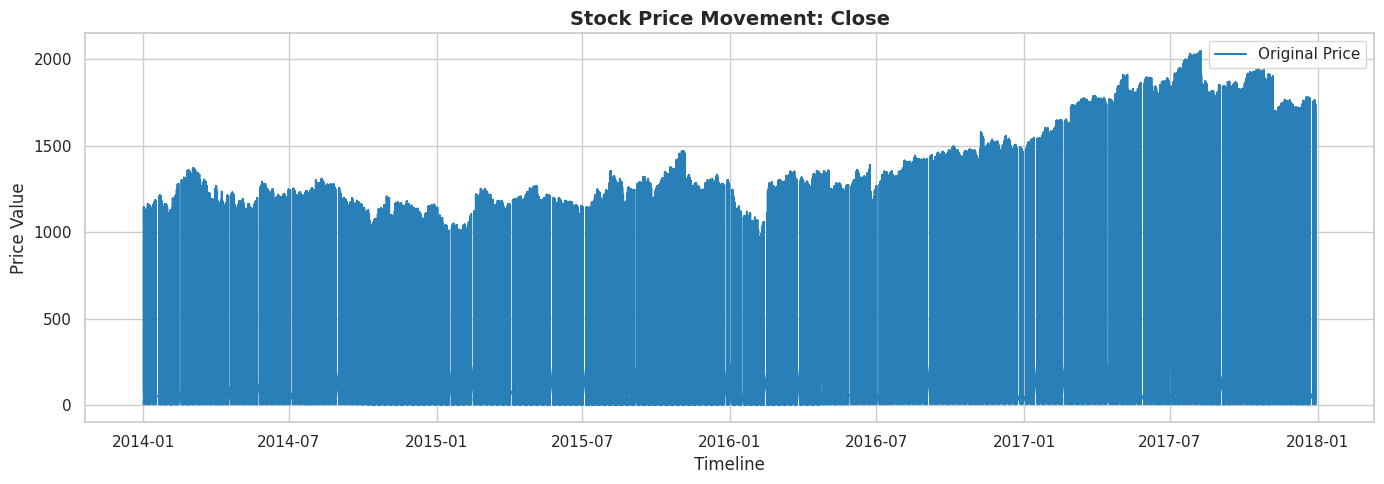

In [ ]:
ts_pipeline.plot_raw_series()


=== PHASE 2: TIME SERIES DECOMPOSITION ===


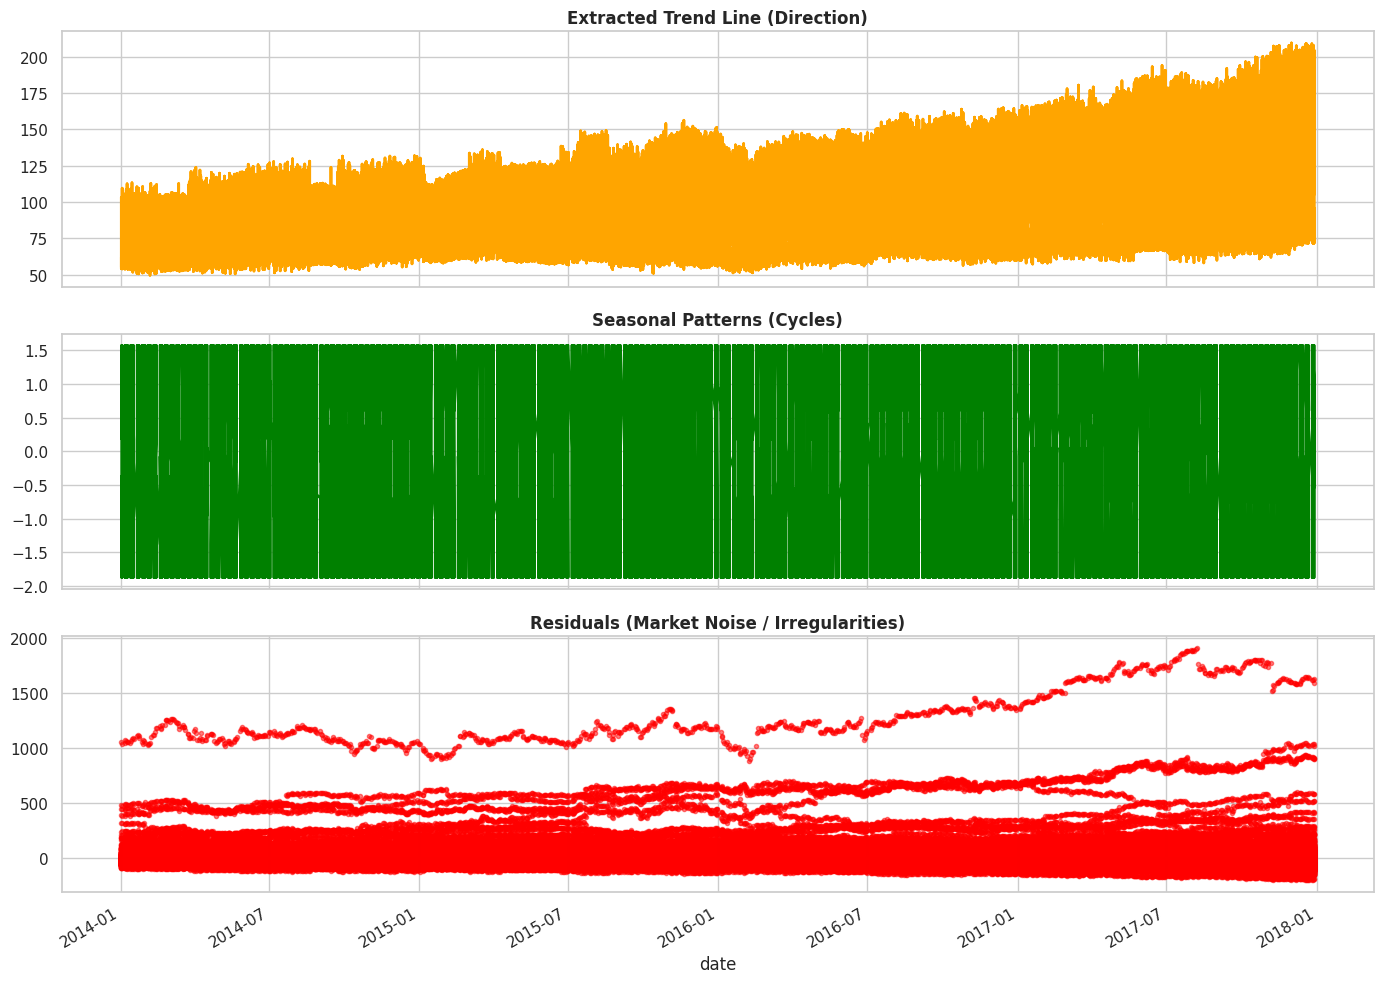

In [ ]:
ts_pipeline.perform_decomposition()


=== PHASE 3: MOVING AVERAGE SMOOTHING (20-Day) ===


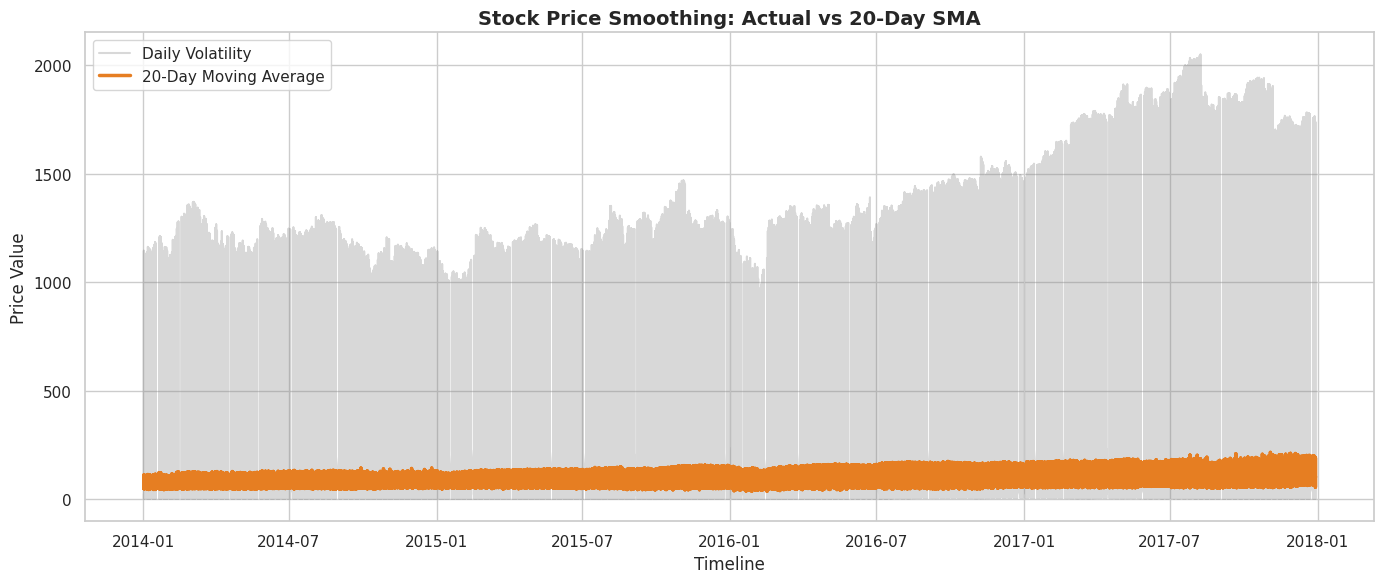

In [ ]:
  ts_pipeline.apply_moving_average(window=20) # 20-day window for clearer trend